In [49]:
import pandas as pd
datos = pd.read_csv('flota_mantenimiento.csv')
datos.head()

,edad_meses,km_recorridos,carga_promedio,tipo_ruta,plan_preventivo,costo_mantenimiento
0,70.0,6.9,11.7,Larga Distancia,No,7275.02
1,78.0,8.8,21.5,Urbana,No,6102.16
2,97.0,9.7,20.1,Urbana,Si,4927.06
3,65.0,10.7,21.7,Urbana,No,7067.11
4,18.0,9.2,22.3,Urbana,No,4396.42


**1. Revisión de estructura y tipo de variables (EDA)**

- cuantitativas continuas: edad, km, carga, costo

- categóricas: tipo_ruta, plan_preventivo

**3. Revisar calidad de datos**

- Valores Faltantes 
- Registros duplicados
- Valores imposibles inchorentes 


In [50]:
import pandas as pd
df = pd.read_csv('flota_mantenimiento.csv')
valores_faltantes = df.isnull().sum()
porcentaje_faltantes = (valores_faltantes / len(df)) * 100
print(f"Porcentaje de valores faltantes: {porcentaje_faltantes}")


Porcentaje de valores faltantes: edad_meses             0.0
km_recorridos          0.0
carga_promedio         0.0
tipo_ruta              0.0
plan_preventivo        0.0
costo_mantenimiento    0.0
dtype: float64


In [51]:

print(f"Número de filas duplicadas: {df.duplicated().sum()}")

# Ver los duplicados (opcional)
df[df.duplicated()]

# Eliminar duplicados (si decides hacerlo)
df = df.drop_duplicates()

Número de filas duplicadas: 0


In [52]:
# Revisar mínimos y máximos
df.describe()

,edad_meses,km_recorridos,carga_promedio,costo_mantenimiento
count,500.000000,500.000000,500.000000,500.000000
mean,48.152000,8.530600,18.084600,5307.991060
std,18.261211,2.564566,6.005607,2038.436814
min,6.000000,2.000000,5.000000,1130.510000
25%,35.000000,6.600000,13.875000,3701.132500
50%,47.000000,8.500000,18.200000,5102.335000
75%,60.250000,10.200000,21.825000,6574.682500
max,113.000000,17.000000,35.000000,12473.540000


In [53]:
# Ver valores muy altos (top 5)
df.sort_values(by="costo_mantenimiento", ascending=False).head()

df.sort_values(by="km_recorridos", ascending=False).head()

,edad_meses,km_recorridos,carga_promedio,tipo_ruta,plan_preventivo,costo_mantenimiento
254,79.0,17.0,27.7,Urbana,Si,6698.33
10,53.0,16.6,33.9,Urbana,No,9662.66
313,28.0,15.1,35.0,Urbana,Si,6280.79
260,52.0,14.5,29.5,Urbana,No,7086.59
159,33.0,14.5,32.3,Larga Distancia,No,8105.72


In [54]:
cont_valores_sinSentido = len(df[df["costo_mantenimiento"] < 0])
print(f"Número de valores sin sentido: {cont_valores_sinSentido}")
valores_sin_sentido = df[df["costo_mantenimiento"] < 0]
print(valores_sin_sentido)


Número de valores sin sentido: 0
Empty DataFrame
Columns: [edad_meses, km_recorridos, carga_promedio, tipo_ruta, plan_preventivo, costo_mantenimiento]
Index: []


In [55]:
Q1 = df["costo_mantenimiento"].quantile(0.25)
Q3 = df["costo_mantenimiento"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Q1: 3701.1325
Q3: 6574.6825
IQR: 2873.5499999999997
Límite inferior: -609.1924999999997
Límite superior: 10885.0075


In [56]:
valores_fuera_rango = df[(df["costo_mantenimiento"] < limite_inferior) | (df["costo_mantenimiento"] > limite_superior)]
print(f"Número de valores fuera de rango: {len(valores_fuera_rango)}")
print(valores_fuera_rango)


Número de valores fuera de rango: 4
     edad_meses  km_recorridos  carga_promedio        tipo_ruta  \
180        70.0           12.9            26.0  Larga Distancia   
182       104.0           14.0            26.3           Urbana   
251        62.0           11.5            29.2  Larga Distancia   
371        94.0           12.6            23.7           Urbana   

    plan_preventivo  costo_mantenimiento  
180              No             12473.54  
182              No             11632.49  
251              No             11783.21  
371              No             11449.17  


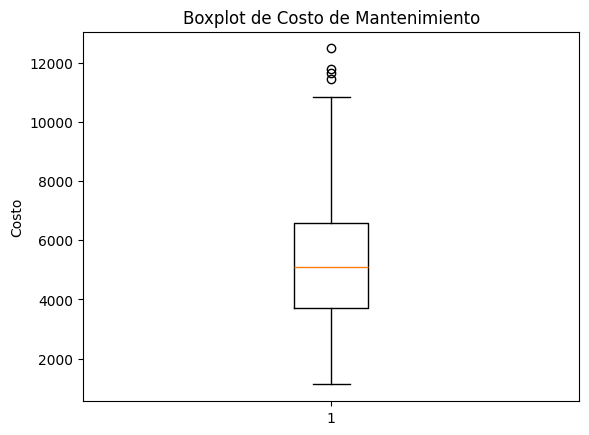

In [57]:
import matplotlib.pyplot as plt

# Boxplot de costo
plt.boxplot(df["costo_mantenimiento"])
plt.title("Boxplot de Costo de Mantenimiento")
plt.ylabel("Costo")
plt.show()

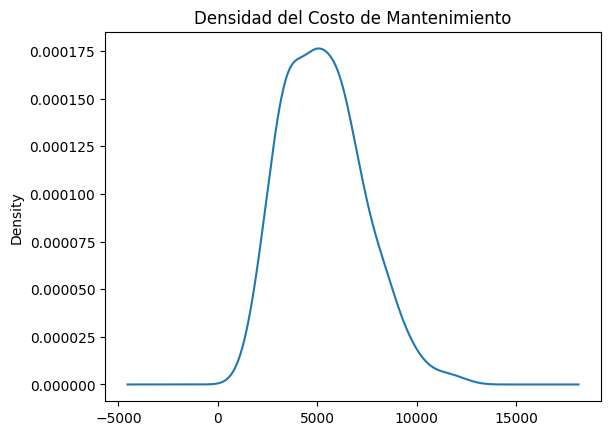

In [58]:
df["costo_mantenimiento"].plot(kind="density")
plt.title("Densidad del Costo de Mantenimiento")
plt.show()

**Distribución de `costo_mantenimiento`**

Resumen: forma de la distribución, asimetría (sesgo), evidencia de cola derecha y valores más extremos. Complementa boxplot y densidad ya calculados arriba.


Resumen numérico (incl. percentiles)


count      500.000000
mean      5307.991060
std       2038.436814
min       1130.510000
5%        2400.500500
25%       3701.132500
50%       5102.335000
75%       6574.682500
95%       8859.366500
max      12473.540000
Name: costo_mantenimiento, dtype: float64

Asimetría (sesgo de Fisher): 0.5091
Sesgo positivo claro: la masa está más a la izquierda y hay cola hacia valores altos (derecha).
Curtosis (exceso, normal≈0): 0.0256  — valores altos sugieren colas más gruesas que la normal.
Mediana: 5102.34  |  Media: 5307.99  |  P99: 10684.07  |  Máx: 12473.54
La media supera la mediana → coherente con asimetría positiva y cola derecha.

Registros con los 10 mayores costos (revisar si son plausibles o outliers operativos):


,edad_meses,km_recorridos,carga_promedio,tipo_ruta,plan_preventivo,costo_mantenimiento
180,70.0,12.9,26.0,Larga Distancia,No,12473.54
251,62.0,11.5,29.2,Larga Distancia,No,11783.21
182,104.0,14.0,26.3,Urbana,No,11632.49
371,94.0,12.6,23.7,Urbana,No,11449.17
219,51.0,13.1,31.0,Larga Distancia,No,10845.96
199,76.0,9.2,11.4,Larga Distancia,No,10682.43
127,68.0,13.0,25.0,Larga Distancia,No,10560.89
65,113.0,11.6,18.2,Urbana,No,10233.87
320,85.0,12.8,24.4,Urbana,No,10191.21
118,72.0,11.4,19.4,Larga Distancia,No,9849.54


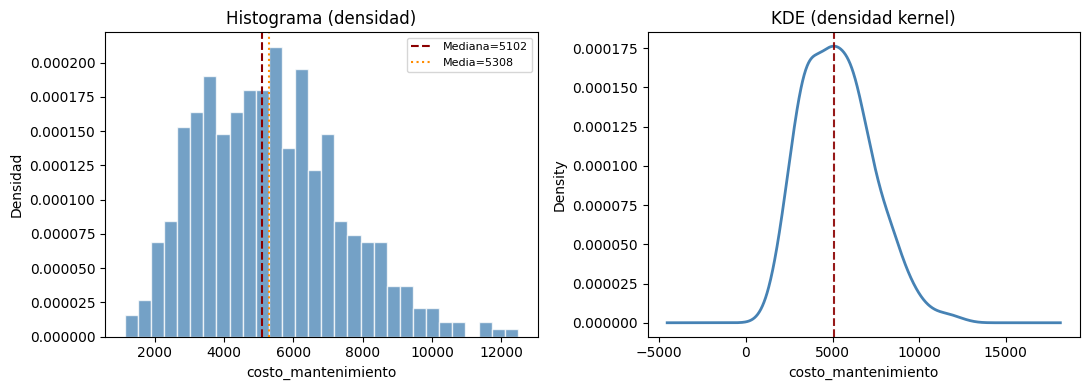

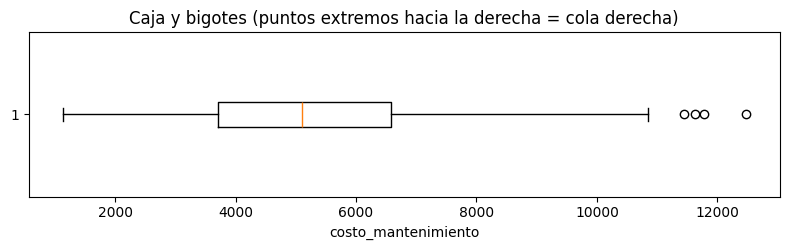

In [59]:
from IPython.display import display
import matplotlib.pyplot as plt

col = "costo_mantenimiento"
x = df[col]

print("Resumen numérico (incl. percentiles)")
display(x.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

asimetria = x.skew()
curtosis = x.kurtosis()
med, mu = x.median(), x.mean()
p99 = x.quantile(0.99)

print(f"Asimetría (sesgo de Fisher): {asimetria:.4f}")
if asimetria > 0.5:
    interp_skew = "Sesgo positivo claro: la masa está más a la izquierda y hay cola hacia valores altos (derecha)."
elif asimetria < -0.5:
    interp_skew = "Sesgo negativo: cola hacia valores bajos."
else:
    interp_skew = "Sesgo moderado (entre −0.5 y 0.5): forma relativamente simétrica."

print(interp_skew)
print(f"Curtosis (exceso, normal≈0): {curtosis:.4f}  — valores altos sugieren colas más gruesas que la normal.")
print(f"Mediana: {med:.2f}  |  Media: {mu:.2f}  |  P99: {p99:.2f}  |  Máx: {x.max():.2f}")
if mu > med:
    print("La media supera la mediana → coherente con asimetría positiva y cola derecha.")
elif mu < med:
    print("La media está por debajo de la mediana → coherente con cola izquierda.")

print("\nRegistros con los 10 mayores costos (revisar si son plausibles o outliers operativos):")
display(
    df.nlargest(10, col)[
        ["edad_meses", "km_recorridos", "carga_promedio", "tipo_ruta", "plan_preventivo", col]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(x, bins=30, density=True, alpha=0.75, edgecolor="white", color="steelblue")
axes[0].axvline(med, color="darkred", linestyle="--", label=f"Mediana={med:.0f}")
axes[0].axvline(mu, color="darkorange", linestyle=":", label=f"Media={mu:.0f}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Densidad")
axes[0].set_title("Histograma (densidad)")
axes[0].legend(fontsize=8)
x.plot(kind="density", ax=axes[1], color="steelblue", linewidth=2, legend=False)
axes[1].axvline(med, color="darkred", linestyle="--", alpha=0.9)
axes[1].set_xlabel(col)
axes[1].set_title("KDE (densidad kernel)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.boxplot(x, vert=False)
ax.set_xlabel(col)
ax.set_title("Caja y bigotes (puntos extremos hacia la derecha = cola derecha)")
plt.tight_layout()
plt.show()


- El análisis de costo_mantenimiento muestra que, en general, la mayoría de los valores se concentran en una sola zona, pero hay algunos casos con costos bastante más altos de lo normal. Eso se nota porque el promedio sale un poco por encima de la mediana, lo que sugiere que esos valores altos están empujando el resultado hacia arriba. También aparecen algunos vehículos con costos de mantenimiento especialmente elevados, aunque no necesariamente significa que haya errores en los datos; más bien podrían ser casos reales dentro de la operación. En resumen, esta variable parece tener algo de variación importante entre vehículos, así que vale la pena revisarla bien más adelante cuando se evalúe el modelo.

,edad_meses,km_recorridos,carga_promedio,costo_mantenimiento
edad_meses,1.0000,0.2952,-0.0128,0.4290
km_recorridos,0.2952,1.0000,0.7985,0.6157
carga_promedio,-0.0128,0.7985,1.0000,0.4862
costo_mantenimiento,0.4290,0.6157,0.4862,1.0000


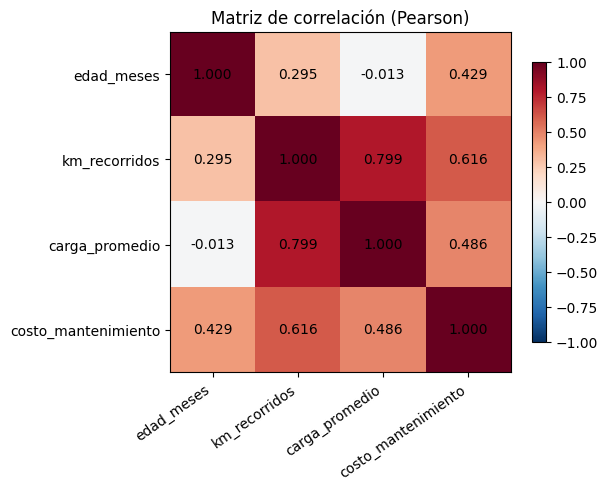

In [60]:
# Variables cuantitativas: matriz de correlación de Pearson
from IPython.display import display

vars_cuant = ["edad_meses", "km_recorridos", "carga_promedio", "costo_mantenimiento"]
matriz_corr = df[vars_cuant].corr(method="pearson")
display(matriz_corr.round(4))

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6.2, 5))
M = matriz_corr.values
im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(vars_cuant)))
ax.set_yticks(np.arange(len(vars_cuant)))
ax.set_xticklabels(vars_cuant, rotation=35, ha="right")
ax.set_yticklabels(vars_cuant)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i, j]:.3f}", ha="center", va="center", fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.82)
ax.set_title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()


In [61]:
columnas = [c for c in df.columns if c != "costo_mantenimiento" and c!="plan_preventivo" and c!="tipo_ruta"]
for col in columnas:
    corr = df["costo_mantenimiento"].corr(df[col])
    print(f"La columna: {col} tiene una correlación de {corr} con costo")

La columna: edad_meses tiene una correlación de 0.42903986725453436 con costo
La columna: km_recorridos tiene una correlación de 0.6156591464734831 con costo
La columna: carga_promedio tiene una correlación de 0.48619184404102694 con costo


- Todas las variables numéricas se relacionan positivamente con el costo

- Hay una correlación muy alta entre km_recorridos y carga_promedio, Eso es una señal importante de posible multicolinealidad.



In [62]:
import pandas as pd
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# Variables
x = df["edad_meses"].values
y = df["costo_mantenimiento"].values

# 1. LOWESS
suavizada = lowess(y, x, frac=0.3, return_sorted=True)

# 2. Extraer y estabilizar la curva para derivar en malla uniforme
x_suave = suavizada[:, 0]
y_suave = suavizada[:, 1]
x_unico, idx_unico = np.unique(x_suave, return_index=True)
y_unico = y_suave[idx_unico]

n_grid = max(200, len(x_unico))
x_grid = np.linspace(x_unico.min(), x_unico.max(), n_grid)
y_grid = np.interp(x_grid, x_unico, y_unico)

# 3. Calcular pendiente y curvatura geométrica
pendiente = np.gradient(y_grid, x_grid)
d2 = np.gradient(pendiente, x_grid)
curvatura = d2 / (1 + pendiente**2) ** 1.5
curvatura_abs = np.abs(curvatura)

# 4. Ignorar extremos (10% a cada lado)
n = len(x_grid)
inicio = int(n * 0.10)
fin = int(n * 0.90)

x_central = x_grid[inicio:fin]
y_central = y_grid[inicio:fin]
curv_central = curvatura[inicio:fin]
curv_abs_central = curvatura_abs[inicio:fin]

# 5. Punto con mayor curvatura
idx_local = np.argmax(curv_abs_central)

edad_max_curv = x_central[idx_local]
costo_max_curv = y_central[idx_local]
valor_curv = curv_central[idx_local]

print("Mayor curvatura en la zona central:")
print("Edad aproximada:", edad_max_curv)
print("Costo suavizado aproximado:", costo_max_curv)
print("Curvatura:", valor_curv)

# 8. Tabla de apoyo
tabla_curvatura = pd.DataFrame({
    "edad": x_grid,
    "costo_suavizado": y_grid,
    "pendiente": pendiente,
    "curvatura": curvatura,
    "curvatura_absoluta": curvatura_abs
})

tabla_top = (
    tabla_curvatura.iloc[inicio:fin]
    .sort_values("curvatura_absoluta", ascending=False)
    .head(10)
)

print("\nTop 10 edades con mayor curvatura:")
print(tabla_top)

Mayor curvatura en la zona central:
Edad aproximada: 55.46733668341709
Costo suavizado aproximado: 5812.672992846158
Curvatura: -1.4102180552133579

Top 10 edades con mayor curvatura:
         edad  costo_suavizado  pendiente  curvatura  curvatura_absoluta
92  55.467337      5812.672993  -1.254890  -1.410218            1.410218
47  31.271357      4469.922638   2.404136   0.275078            0.275078
45  30.195980      4468.430503   1.878155  -0.199803            0.199803
44  29.658291      4466.880988   3.457433  -0.162332            0.162332
46  30.733668      4468.900712   1.387547   0.097759            0.097759
48  31.809045      4471.486065   6.609683   0.030961            0.030961
93  56.005025      5810.675335  12.286863   0.014919            0.014919
43  29.120603      4464.712460  10.017000  -0.013011            0.013011
91  54.929648      5812.024815  18.552271  -0.005945            0.005945
42  28.582915      4456.108938  17.731239  -0.004317            0.004317


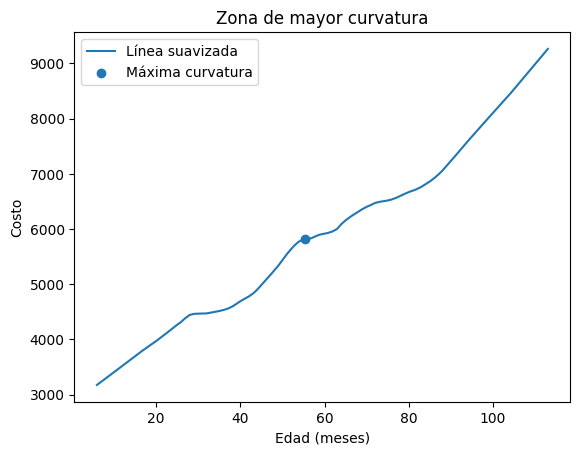

In [63]:
import matplotlib.pyplot as plt

plt.plot(x_grid, y_grid, label="Línea suavizada")
plt.scatter([edad_max_curv], [costo_max_curv], label="Máxima curvatura")
plt.xlabel("Edad (meses)")
plt.ylabel("Costo")
plt.title("Zona de mayor curvatura")
plt.legend()
plt.show()

Variable: Km recorridos


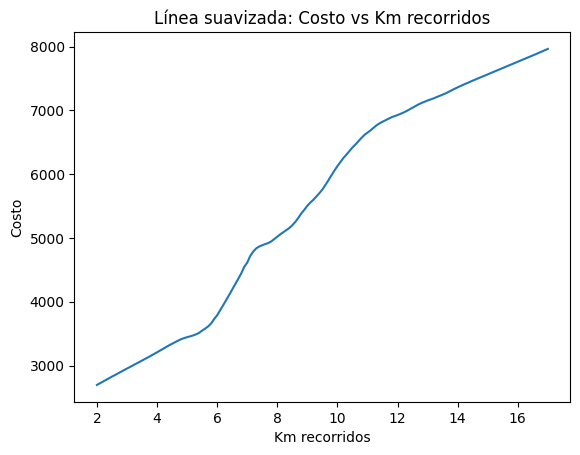


Mayor curvatura en la zona central (Km recorridos):
  Km recorridos aproximado: 5.316582914572864
  Costo suavizado aproximado: 3493.6259117365275
  Curvatura: 7.90138251778567e-05

Top 10 valores de Km recorridos con mayor curvatura:
     km_recorridos  costo_suavizado   pendiente  curvatura  curvatura_absoluta
44        5.316583      3493.625912  208.431327   0.000079            0.000079
38        4.864322      3423.918782  169.599631  -0.000078            0.000078
76        7.728643      4927.274846  229.787419   0.000077            0.000077
42        5.165829      3466.873453  148.630466   0.000075            0.000075
43        5.241206      3479.063908  177.457977   0.000071            0.000071
72        7.427136      4871.513354  225.779182  -0.000069            0.000069
39        4.939698      3435.555591  144.643220  -0.000065            0.000065
75        7.653266      4912.648487  179.202011   0.000061            0.000061
130      11.798995      6891.849495  207.137622  -0.0

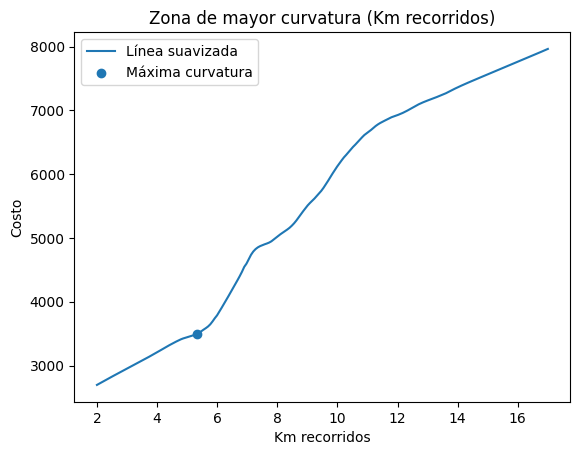

Variable: Carga promedio


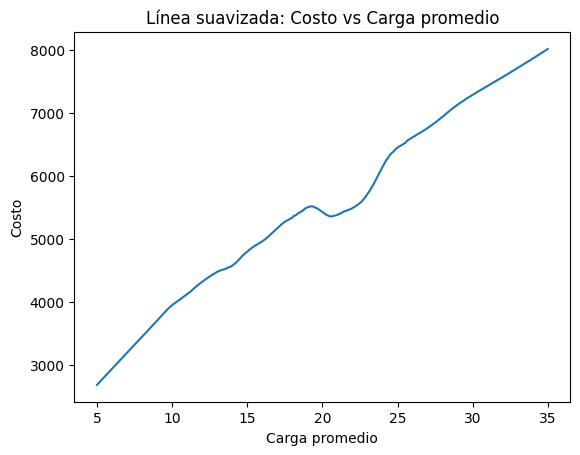


Mayor curvatura en la zona central (Carga promedio):
  Carga promedio aproximado: 20.51724137931035
  Costo suavizado aproximado: 5355.4841778975515
  Curvatura: 0.010140653156415805

Top 10 valores de Carga promedio con mayor curvatura:
     carga_promedio  costo_suavizado   pendiente  curvatura  \
105       20.517241      5355.484178  -36.312398   0.010141   
106       20.665025      5357.822310   34.033895   0.008586   
96        19.187192      5511.839953   37.854750  -0.008291   
97        19.334975      5512.979001  -40.830642  -0.006818   
107       20.812808      5365.543457   63.858215   0.000711   
95        19.039409      5501.790405   92.238756  -0.000501   
98        19.482759      5499.771783  -99.432887  -0.000292   
104       20.369458      5368.555038 -109.640637   0.000282   
108       20.960591      5376.696659   88.777270   0.000213   
56        13.275862      4500.637593   83.735056  -0.000158   

     curvatura_absoluta  
105            0.010141  
106            

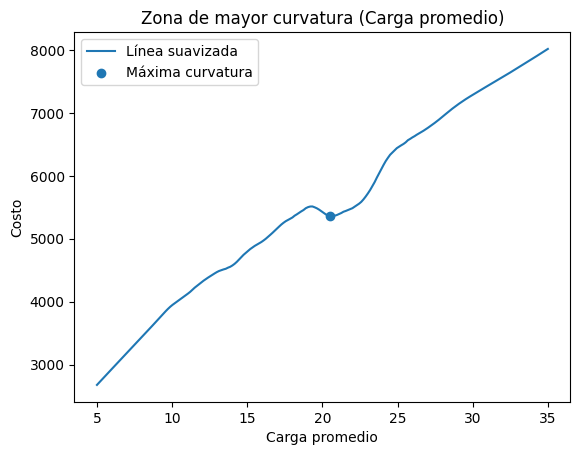

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

y = df["costo_mantenimiento"]

for col, etiqueta_x in [
    ("km_recorridos", "Km recorridos"),
    ("carga_promedio", "Carga promedio"),
]:
    print("=" * 60)
    print(f"Variable: {etiqueta_x}")
    print("=" * 60)
    x = df[col]
    x_ordenado = np.sort(x)

    

    plt.figure()
    suav_simple = lowess(y, x, frac=0.3)
    plt.plot(suav_simple[:, 0], suav_simple[:, 1])
    plt.xlabel(etiqueta_x)
    plt.ylabel("Costo")
    plt.title(f"Línea suavizada: Costo vs {etiqueta_x}")
    plt.show()

    xv = x.values
    yv = y.values
    suavizada = lowess(yv, xv, frac=0.3, return_sorted=True)

    # Evitar inestabilidad numérica con x repetidos y espaciado irregular:
    # se interpola la curva LOWESS en una malla uniforme y allí se derivan.
    x_suave = suavizada[:, 0]
    y_suave = suavizada[:, 1]
    x_unico, idx_unico = np.unique(x_suave, return_index=True)
    y_unico = y_suave[idx_unico]

    n_grid = max(200, len(x_unico))
    x_grid = np.linspace(x_unico.min(), x_unico.max(), n_grid)
    y_grid = np.interp(x_grid, x_unico, y_unico)

    pendiente = np.gradient(y_grid, x_grid)
    d2 = np.gradient(pendiente, x_grid)
    curvatura = d2 / (1 + pendiente**2) ** 1.5
    curvatura_abs = np.abs(curvatura)

    n = len(x_grid)
    inicio = int(n * 0.10)
    fin = int(n * 0.90)
    x_central = x_grid[inicio:fin]
    y_central = y_grid[inicio:fin]
    curv_central = curvatura[inicio:fin]

    idx_local = np.argmax(curvatura_abs[inicio:fin])
    x_max_curv = x_central[idx_local]
    costo_max_curv = y_central[idx_local]
    valor_curv = curv_central[idx_local]

    print(f"\nMayor curvatura en la zona central ({etiqueta_x}):")
    print(f"  {etiqueta_x} aproximado:", x_max_curv)
    print("  Costo suavizado aproximado:", costo_max_curv)
    print("  Curvatura:", valor_curv)

    tabla_curvatura = pd.DataFrame({
        col: x_grid,
        "costo_suavizado": y_grid,
        "pendiente": pendiente,
        "curvatura": curvatura,
        "curvatura_absoluta": curvatura_abs,
    })
    tabla_top = (
        tabla_curvatura.iloc[inicio:fin]
        .sort_values("curvatura_absoluta", ascending=False)
        .head(10)
    )
    print(f"\nTop 10 valores de {etiqueta_x} con mayor curvatura:")
    print(tabla_top)

    plt.figure()
    plt.plot(x_grid, y_grid, label="Línea suavizada")
    plt.scatter([x_max_curv], [costo_max_curv], label="Máxima curvatura")
    plt.xlabel(etiqueta_x)
    plt.ylabel("Costo")
    plt.title(f"Zona de mayor curvatura ({etiqueta_x})")
    plt.legend()
    plt.show()

- Las tres variables muestran algún indicio de no linealidad, pero no con la misma intensidad ni con la misma claridad

- Las curvas suavizadas sugieren que las relaciones entre costo_mantenimiento y las variables edad_meses, km_recorridos y carga_promedio no siguen de manera estricta una forma lineal en todo su rango. En los tres casos se observan cambios en la pendiente, aunque con distinta intensidad. La evidencia visual es más clara para edad_meses y km_recorridos, mientras que en carga_promedio la posible no linealidad parece más localizada. Por ello, resulta razonable evaluar especificaciones alternativas que incorporen términos cuadráticos.

In [65]:
# 1) Frecuencia por categoría
print("Frecuencia de tipo_ruta:")
print(df["tipo_ruta"].value_counts(dropna=False))
print("\nProporción de tipo_ruta:")
print(df["tipo_ruta"].value_counts(normalize=True, dropna=False).round(3))

print("\nFrecuencia de plan_preventivo:")
print(df["plan_preventivo"].value_counts(dropna=False))
print("\nProporción de plan_preventivo:")
print(df["plan_preventivo"].value_counts(normalize=True, dropna=False).round(3))

Frecuencia de tipo_ruta:
tipo_ruta
Urbana             311
Larga Distancia    189
Name: count, dtype: int64

Proporción de tipo_ruta:
tipo_ruta
Urbana             0.622
Larga Distancia    0.378
Name: proportion, dtype: float64

Frecuencia de plan_preventivo:
plan_preventivo
No    348
Si    152
Name: count, dtype: int64

Proporción de plan_preventivo:
plan_preventivo
No    0.696
Si    0.304
Name: proportion, dtype: float64


Las variables categóricas presentan una distribución adecuada para el análisis. En tipo_ruta, el 62.2% de los camiones corresponde a rutas urbanas y el 37.8% a larga distancia. Por su parte, en plan_preventivo, el 69.6% de los vehículos no pertenece al programa y el 30.4% sí se encuentra vinculado. Aunque la muestra no está completamente balanceada, todas las categorías cuentan con un número suficiente de observaciones, lo que permite realizar comparaciones entre grupos e incorporarlas posteriormente en el modelo mediante variables dicotómicas.

In [ ]:
# 2) Tabla resumen de costo por grupo
print("Resumen por tipo_ruta:")
resumen_ruta = df.groupby("tipo_ruta")["costo_mantenimiento"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    max="max"
).round(2)
print(resumen_ruta)

print("\nResumen por plan_preventivo:")
resumen_plan = df.groupby("plan_preventivo")["costo_mantenimiento"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    max="max"
).round(2)
print(resumen_plan)

Resumen por tipo_ruta:
                 count     mean   median      std      min       q1       q3  \
tipo_ruta                                                                      
Larga Distancia    189  6009.50  5857.43  2077.22  1901.59  4574.93  7402.82   
Urbana             311  4881.67  4686.04  1894.59  1130.51  3458.40  6203.21   

                      max  
tipo_ruta                  
Larga Distancia  12473.54  
Urbana           11632.49  

Resumen por plan_preventivo:
                 count     mean   median      std      min       q1       q3  \
plan_preventivo                                                                
No                 348  5979.73  5973.91  1928.21  1759.84  4605.03  7159.16   
Si                 152  3770.06  3651.72  1329.15  1130.51  2789.18  4733.38   

                      max  
plan_preventivo            
No               12473.54  
Si                8002.13  


Los resultados descriptivos muestran diferencias claras en el costo de mantenimiento según las variables categóricas. En el caso de tipo_ruta, los camiones asignados a larga distancia presentan mayores costos que los de ruta urbana, tanto en promedio (6009.50 vs 4881.07) como en mediana (5857.43 vs 4686.04). Por su parte, la diferencia asociada a plan_preventivo es aún más marcada: los vehículos sin plan registran costos sustancialmente más altos que aquellos vinculados al programa, con una media de 5979.73 frente a 3770.06 y una mediana de 5973.91 frente a 3651.72. Además, los grupos sin plan preventivo y de larga distancia exhiben mayores niveles de dispersión y máximos más elevados, lo que sugiere no solo mayores costos esperados, sino también mayor riesgo de eventos costosos.

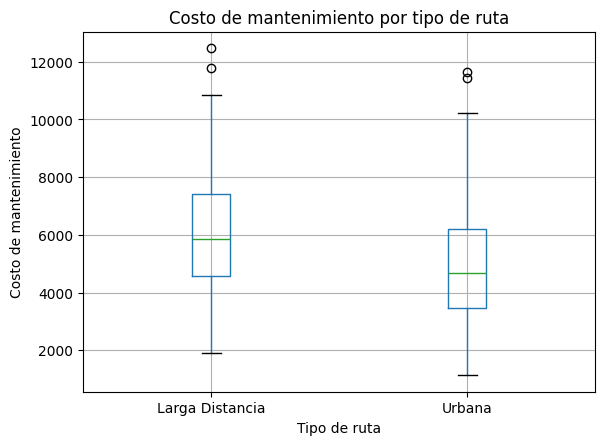

In [67]:
# 3) Boxplot por tipo_ruta
import matplotlib.pyplot as plt

df.boxplot(column="costo_mantenimiento", by="tipo_ruta")
plt.title("Costo de mantenimiento por tipo de ruta")
plt.suptitle("")
plt.xlabel("Tipo de ruta")
plt.ylabel("Costo de mantenimiento")
plt.show()

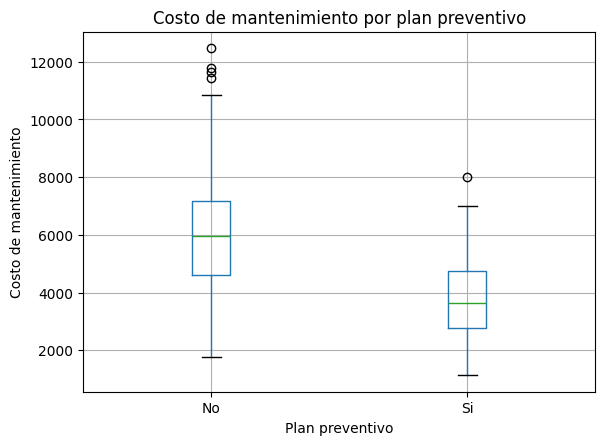

In [68]:
# 4) Boxplot por plan_preventivo
df.boxplot(column="costo_mantenimiento", by="plan_preventivo")
plt.title("Costo de mantenimiento por plan preventivo")
plt.suptitle("")
plt.xlabel("Plan preventivo")
plt.ylabel("Costo de mantenimiento")
plt.show()

In [69]:
# 5) Promedio y mediana por categoría (más limpio para comparar)
promedios_ruta = df.groupby("tipo_ruta")["costo_mantenimiento"].mean().round(2)
medianas_ruta = df.groupby("tipo_ruta")["costo_mantenimiento"].median().round(2)

promedios_plan = df.groupby("plan_preventivo")["costo_mantenimiento"].mean().round(2)
medianas_plan = df.groupby("plan_preventivo")["costo_mantenimiento"].median().round(2)

print("Promedios por tipo_ruta:")
print(promedios_ruta)
print("\nMedianas por tipo_ruta:")
print(medianas_ruta)

print("\nPromedios por plan_preventivo:")
print(promedios_plan)
print("\nMedianas por plan_preventivo:")
print(medianas_plan)

Promedios por tipo_ruta:
tipo_ruta
Larga Distancia    6009.50
Urbana             4881.67
Name: costo_mantenimiento, dtype: float64

Medianas por tipo_ruta:
tipo_ruta
Larga Distancia    5857.43
Urbana             4686.04
Name: costo_mantenimiento, dtype: float64

Promedios por plan_preventivo:
plan_preventivo
No    5979.73
Si    3770.06
Name: costo_mantenimiento, dtype: float64

Medianas por plan_preventivo:
plan_preventivo
No    5973.91
Si    3651.72
Name: costo_mantenimiento, dtype: float64


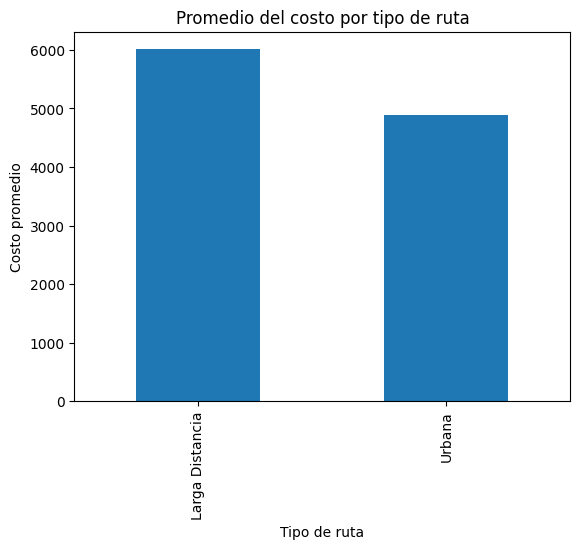

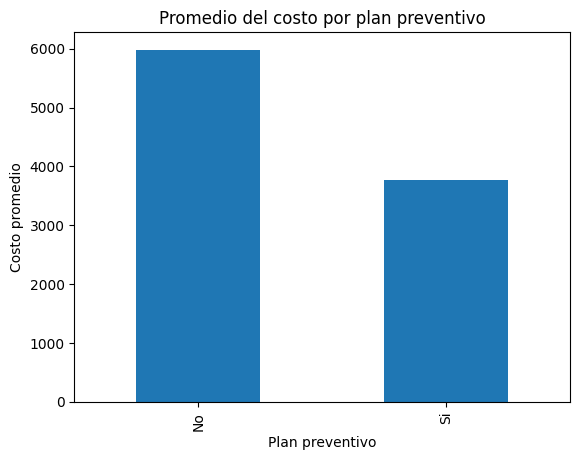

In [70]:
# 6) Barras con promedio por categoría
promedios_ruta.plot(kind="bar")
plt.title("Promedio del costo por tipo de ruta")
plt.xlabel("Tipo de ruta")
plt.ylabel("Costo promedio")
plt.show()

promedios_plan.plot(kind="bar")
plt.title("Promedio del costo por plan preventivo")
plt.xlabel("Plan preventivo")
plt.ylabel("Costo promedio")
plt.show()

Las gráficas de promedios refuerzan los hallazgos previos del análisis exploratorio. En particular, los camiones asignados a rutas de larga distancia presentan un costo promedio de mantenimiento superior al de los vehículos urbanos. Por otra parte, la diferencia más marcada se observa en la variable plan_preventivo, donde los vehículos que no pertenecen al programa registran un costo promedio considerablemente mayor que aquellos que sí están cubiertos por dicho plan.

Modelo Base:

                             OLS Regression Results                            
Dep. Variable:     costo_mantenimiento   R-squared:                       0.823
Model:                             OLS   Adj. R-squared:                  0.821
Method:                  Least Squares   F-statistic:                     460.1
Date:                 Fri, 27 Mar 2026   Prob (F-statistic):          2.89e-183
Time:                         21:32:06   Log-Likelihood:                -4085.7
No. Observations:                  500   AIC:                             8183.
Df Residuals:                      494   BIC:                             8209.
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               1038.4

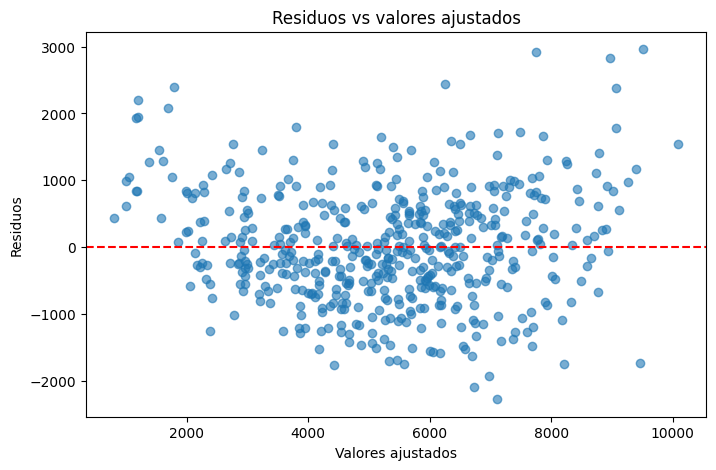

In [77]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Cargar la base
df = pd.read_csv("flota_mantenimiento.csv")

# 2. Crear dummies para las categóricas
df_modelo = pd.get_dummies(
    df,
    columns=["tipo_ruta", "plan_preventivo"],
    drop_first=True,
    dtype=int
)

# 3. Variable dependiente
y = df_modelo["costo_mantenimiento"]

# 4. Variables explicativas del modelo base
X = df_modelo[[
    "edad_meses",
    "km_recorridos",
    "carga_promedio",
    "tipo_ruta_Urbana",
    "plan_preventivo_Si"
]]

# 5. Agregar constante
X = sm.add_constant(X)

# 6. Ajustar modelo OLS
modelo_base = sm.OLS(y, X).fit()

# 7. Ver resumen
print(modelo_base.summary())

# 8. Gráfico residuos vs ajustados
ajustados = modelo_base.fittedvalues
residuos = modelo_base.resid

plt.figure(figsize=(8, 5))
plt.scatter(ajustados, residuos, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs valores ajustados")
plt.show()

- Valores ajustados bajos hay varios residuos positivos

- En la parte media aparecen muchos residuos negativos

- En valores ajustados altos vuelven a aparecer más residuos positivos

El modelo base todavía no captura completamente la forma de la relación, o sea, posible no linealidad, eso se alinea con la exploración que hicimos en el EDA, que sospechabamos que varias varaibles eran no lineales.


- Heterocedasticidad: No es un abanico exagerado, pero sí hay indicios de que la variabilidad de los residuos cambia con el nivel ajustado.

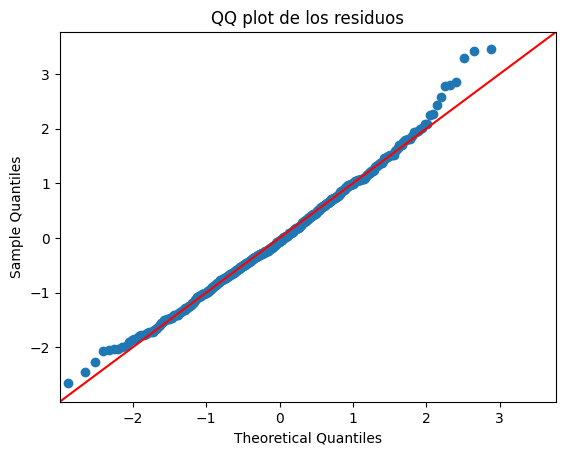

In [78]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot(modelo_base.resid, line='45', fit=True)
plt.title("QQ plot de los residuos")
plt.show()

El gráfico QQ de los residuos muestra que la mayor parte de las observaciones se alinea adecuadamente con la recta teórica, lo que sugiere un comportamiento aproximadamente normal en la zona central de la distribución. Sin embargo, se observan desviaciones en las colas, particularmente en la cola derecha, indicando la presencia de algunos residuos extremos y una normalidad no perfecta. En consecuencia, el supuesto de normalidad puede considerarse razonablemente cumplido en términos generales, aunque con ligeras desviaciones en los extremos

In [79]:
from statsmodels.stats.diagnostic import het_breuschpagan

# prueba Breusch-Pagan
bp_test = het_breuschpagan(modelo_base.resid, modelo_base.model.exog)

labels = ["LM Statistic", "LM-Test p-value", "F-Statistic", "F-Test p-value"]

for name, value in zip(labels, bp_test):
    print(f"{name}: {value}")

LM Statistic: 12.152149641264653
LM-Test p-value: 0.032761418879523364
F-Statistic: 2.461079583878608
F-Test p-value: 0.03225694024612122


La prueba de Breusch-Pagan arrojó un p-valor inferior a 0.05, por lo que se rechaza la hipótesis nula de homocedasticidad. En consecuencia, existe evidencia de heterocedasticidad en los residuos del modelo base. Esto implica que, aunque los coeficientes estimados por MCO pueden seguir siendo consistentes, los errores estándar clásicos no resultan plenamente confiables para la inferencia. Por esta razón, en los pasos posteriores se considerará el uso de errores estándar robustos.

 Diagnóstico base: multicolinealidad (VIF).

In [80]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

             Variable        VIF
0               const  18.484409
1          edad_meses   1.361594
2       km_recorridos   3.743115
3      carga_promedio   3.434664
4    tipo_ruta_Urbana   1.013598
5  plan_preventivo_Si   1.014353


Aunque en la matriz de correlación habías visto una relación alta entre km_recorridos y carga_promedio, al controlar por el resto de variables no aparece una multicolinealidad preocupante.

Para evaluar la presencia de multicolinealidad entre los regresores, se calcularon los factores de inflación de la varianza (VIF). Los resultados muestran valores bajos en todas las variables, con un máximo de 3.74 para km_recorridos y 3.43 para carga_promedio, niveles que no indican un problema severo de colinealidad. En consecuencia, aunque estas dos variables presentan cierta asociación entre sí.

In [81]:
modelo_base_hc3 = sm.OLS(y, X).fit(cov_type="HC3")
print(modelo_base_hc3.summary())

                             OLS Regression Results                            
Dep. Variable:     costo_mantenimiento   R-squared:                       0.823
Model:                             OLS   Adj. R-squared:                  0.821
Method:                  Least Squares   F-statistic:                     331.2
Date:                 Fri, 27 Mar 2026   Prob (F-statistic):          3.39e-155
Time:                         21:47:35   Log-Likelihood:                -4085.7
No. Observations:                  500   AIC:                             8183.
Df Residuals:                      494   BIC:                             8209.
Df Model:                            5                                         
Covariance Type:                   HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               1038.4

Dado que la prueba de Breusch-Pagan evidenció heterocedasticidad, se reestimó el modelo base utilizando errores estándar robustos tipo HC3. Los coeficientes estimados permanecieron inalterados y todas las variables continuaron siendo altamente significativas, lo que indica que los resultados principales del modelo son robustos a la corrección por heterocedasticidad

In [82]:
df_modelo["edad2"] = df_modelo["edad_meses"]**2

X2 = df_modelo[[
    "edad_meses",
    "edad2",
    "km_recorridos",
    "carga_promedio",
    "tipo_ruta_Urbana",
    "plan_preventivo_Si"
]]

X2 = sm.add_constant(X2)

modelo_edad2 = sm.OLS(y, X2).fit(cov_type="HC3")
print(modelo_edad2.summary())

                             OLS Regression Results                            
Dep. Variable:     costo_mantenimiento   R-squared:                       0.824
Model:                             OLS   Adj. R-squared:                  0.821
Method:                  Least Squares   F-statistic:                     277.9
Date:                 Fri, 27 Mar 2026   Prob (F-statistic):          1.21e-154
Time:                         21:49:16   Log-Likelihood:                -4085.3
No. Observations:                  500   AIC:                             8185.
Df Residuals:                      493   BIC:                             8214.
Df Model:                            6                                         
Covariance Type:                   HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               1216.3

Con el fin de capturar la posible no linealidad sugerida en el análisis exploratorio, se estimó una especificación ampliada que incorporó un término cuadrático para **edad_meses**. Sin embargo, dicho término no resultó estadísticamente significativo (**p = 0.449**) y su inclusión no produjo mejoras relevantes en el ajuste del modelo, ya que el **R² ajustado** permaneció inalterado y los criterios de información **AIC** y **BIC** empeoraron ligeramente. En consecuencia, no se encontró evidencia suficiente para justificar la permanencia de esta transformación en la especificación final.

porque tiene mucho sentido que el efecto del uso del camión cambie si está o no bajo mantenimiento preventivo, haremos lo siguiente:

In [ ]:
df_modelo["km_plan"] = df_modelo["km_recorridos"] * df_modelo["plan_preventivo_Si"]

X3 = df_modelo[[
    "edad_meses",
    "km_recorridos",
    "carga_promedio",
    "tipo_ruta_Urbana",
    "plan_preventivo_Si",
    "km_plan"
]]

X3 = sm.add_constant(X3)

modelo_interaccion1 = sm.OLS(y, X3).fit(cov_type="HC3")
print(modelo_interaccion1.summary())

                             OLS Regression Results                            
Dep. Variable:     costo_mantenimiento   R-squared:                       0.833
Model:                             OLS   Adj. R-squared:                  0.831
Method:                  Least Squares   F-statistic:                     306.8
Date:                 Fri, 27 Mar 2026   Prob (F-statistic):          6.93e-163
Time:                         21:57:04   Log-Likelihood:                -4072.1
No. Observations:                  500   AIC:                             8158.
Df Residuals:                      493   BIC:                             8188.
Df Model:                            6                                         
Covariance Type:                   HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                551.0

El modelo mejoró, ya que Posteriormente, se evaluó una especificación con interacción entre **km_recorridos** y **plan_preventivo**, bajo la hipótesis de que el efecto del uso del vehículo sobre el **costo de mantenimiento** podría depender de la existencia de mantenimiento preventivo. El término de interacción resultó estadísticamente significativo y con signo negativo, lo que indica que el plan preventivo atenúa el impacto de los kilómetros recorridos sobre el costo de mantenimiento. Además, esta especificación mejora el ajuste del modelo respecto al modelo base, aumentando el **R² ajustado** y reduciendo los criterios de información **AIC** y **BIC**.

Diagnóstico del modelo mejorado

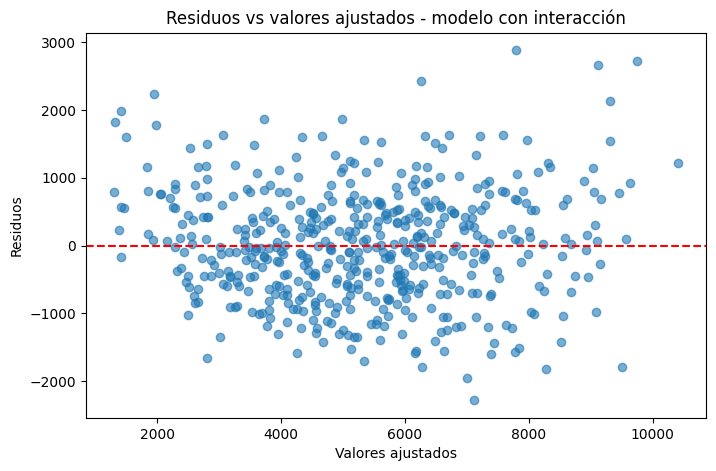

In [84]:
import matplotlib.pyplot as plt

ajustados_int = modelo_interaccion1.fittedvalues
residuos_int = modelo_interaccion1.resid

plt.figure(figsize=(8,5))
plt.scatter(ajustados_int, residuos_int, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs valores ajustados - modelo con interacción")
plt.show()

El gráfico de residuos frente a valores ajustados del modelo con interacción muestra una distribución más equilibrada alrededor de cero en comparación con el modelo base, lo que sugiere una mejora en la especificación. En particular, se reduce el patrón curvo observado previamente, indicando que la interacción incorporada logra capturar parte de la estructura no explicada por el modelo inicial. No obstante, aún se aprecia cierta variación en la dispersión de los residuos para valores ajustados altos, lo que sugiere que la heterocedasticidad podría persistir parcialmente.

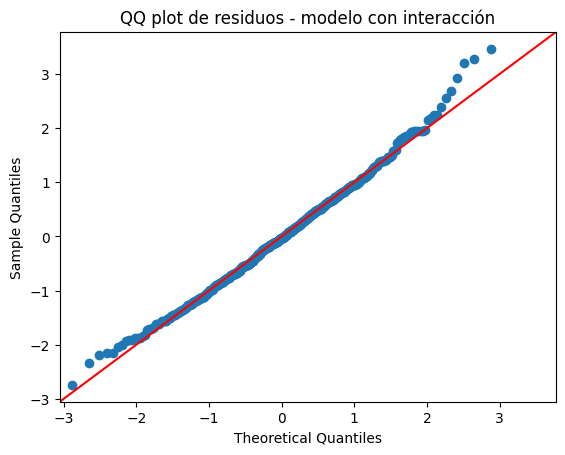

In [85]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot(modelo_interaccion1.resid, line='45', fit=True)
plt.title("QQ plot de residuos - modelo con interacción")
plt.show()

No parece peor; de hecho, se ve igual o ligeramente mejor organizado.

Eso refuerza que el modelo con interacción:

- Mejora la especificación
- No empeora la forma de los residuos


In [86]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test_int = het_breuschpagan(modelo_interaccion1.resid, modelo_interaccion1.model.exog)

labels = ["LM Statistic", "LM-Test p-value", "F-Statistic", "F-Test p-value"]

for name, value in zip(labels, bp_test_int):
    print(f"{name}: {value}")

LM Statistic: 12.37289011718662
LM-Test p-value: 0.05414871085275583
F-Statistic: 2.0848700110346297
F-Test p-value: 0.05355724298737724


Tus p-values
LM p-value = 0.0541
F p-value = 0.0536

Como ambos son mayores que 0.05, no se rechaza h0​ al 5%.



**Conclusión**

Con esta nueva especificación, ya no hay evidencia suficiente de heterocedasticidad al nivel del 5%.

La nueva especificación reduce de manera importante la evidencia de heterocedasticidad. No obstante, dado que los p-valores se encuentran muy próximos al umbral crítico, resulta prudente mantener el uso de errores estándar robustos en la inferencia.

In [87]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data_int = pd.DataFrame()
vif_data_int["Variable"] = X3.columns
vif_data_int["VIF"] = [variance_inflation_factor(X3.values, i) for i in range(X3.shape[1])]

print(vif_data_int)

             Variable        VIF
0               const  24.568786
1          edad_meses   1.361909
2       km_recorridos   4.281433
3      carga_promedio   3.435209
4    tipo_ruta_Urbana   1.015629
5  plan_preventivo_Si  11.519075
6             km_plan  12.131897


El modelo con interacción presenta valores elevados de VIF para plan_preventivo_Si y para el término de interacción,este contexto, la multicolinealidad observada no necesariamente invalida el modelo, pero sí sugiere la conveniencia de centrar la variable km_recorridos antes de construir la interacción, con el fin de mejorar la estabilidad numérica y la interpretación de los coeficientes.

In [88]:
# Centrar km_recorridos
df_modelo["km_c"] = df_modelo["km_recorridos"] - df_modelo["km_recorridos"].mean()

# Nueva interacción con km centrado
df_modelo["km_c_plan"] = df_modelo["km_c"] * df_modelo["plan_preventivo_Si"]

# Nuevo modelo
X4 = df_modelo[[
    "edad_meses",
    "km_c",
    "carga_promedio",
    "tipo_ruta_Urbana",
    "plan_preventivo_Si",
    "km_c_plan"
]]

X4 = sm.add_constant(X4)

modelo_interaccion_c = sm.OLS(y, X4).fit(cov_type="HC3")
print(modelo_interaccion_c.summary())

                             OLS Regression Results                            
Dep. Variable:     costo_mantenimiento   R-squared:                       0.833
Model:                             OLS   Adj. R-squared:                  0.831
Method:                  Least Squares   F-statistic:                     306.8
Date:                 Fri, 27 Mar 2026   Prob (F-statistic):          6.93e-163
Time:                         22:14:53   Log-Likelihood:                -4072.1
No. Observations:                  500   AIC:                             8158.
Df Residuals:                      493   BIC:                             8188.
Df Model:                            6                                         
Covariance Type:                   HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               3525.3

In [89]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data_c = pd.DataFrame()
vif_data_c["Variable"] = X4.columns
vif_data_c["VIF"] = [variance_inflation_factor(X4.values, i) for i in range(X4.shape[1])]

print(vif_data_c)

             Variable        VIF
0               const  56.994857
1          edad_meses   1.361909
2                km_c   4.281433
3      carga_promedio   3.435209
4    tipo_ruta_Urbana   1.015629
5  plan_preventivo_Si   1.014403
6           km_c_plan   1.523858


La multicolinealidad ya no es un problema.

El centrado funcionó exactamente como debía:

plan_preventivo_Si bajó de 11.52 a 1.01
km_c_plan bajó de 12.13 a 1.52

Eso es una mejora enorme.

Entonces el modelo final sería:

Entonces, el modelo final sería:

$$
costo\_mantenimiento_i = \beta_0 + \beta_1 edad\_meses_i + \beta_2 km_{c,i} + \beta_3 carga\_promedio_i + \beta_4 tipo\_ruta\_Urbana_i + \beta_5 plan\_preventivo\_Si_i + \beta_6 \left( km_{c,i} \times plan\_preventivo\_Si_i \right) + \varepsilon_i
$$

donde:

$$
km_c = km\_recorridos - \overline{km\_recorridos}
$$

El modelo definitivo muestra que el costo de mantenimiento correctivo de los camiones depende de factores de antigüedad, intensidad de uso, carga transportada, tipo de ruta y pertenencia al plan preventivo

 **1. Edad del vehículo**: Indica que, manteniendo constantes las demás variables, cada mes adicional de antigüedad incrementa el costo esperado de mantenimiento en aproximadamente 43.65 dólares, sugiere que el envejecimiento de la flota genera un aumento sistemático en los costos correctivos. En consecuencia, la empresa debería considerar la edad del vehículo para renovación.

 **2. Kilómetros recorridos centrados**: Para los camiones sin plan preventivo, un aumento de una unidad en los kilómetros recorridos respecto al promedio incrementa el costo de mantenimiento en aproximadamente 348.66 dólares, confirmamndo que la intensidad de uso del vehículo es uno de los principales determinantes del costo correctivo. Los camiones sometidos a mayor recorrido mensual sufren más desgaste y, por tanto, demandan más gasto en reparación

 **3. Carga promedio**: Transportar cargas más pesadas implica una mayor exigencia mecánica sobre los vehículos, lo que se traduce en costos más altos. Por lo tanto, la empresa debe tener en cuenta el peso transportado como factor de desgaste operativo al diseñar sus políticas de mantenimiento.

 **4. Tipo de ruta**: en comparación con la categoría base (Larga Distancia), los camiones que operan en rutas urbanas presentan un costo de mantenimiento aproximadamente 1227.54 dólares menor. Esto implica que las operaciones de larga distancia son estructuralmente más costosas en términos de mantenimiento.

 **5. Plan preventivo**: para un camión con kilometraje promedio, pertenecer al plan preventivo reduce el costo esperado de mantenimiento en aproximadamente 2290.63 dólares. La evidencia sugiere que el programa de mantenimiento preventivo tiene un efecto económicamente fuerte en la reducción de los costos correctivos

 **6. Interacción entre kilómetros recorridos y plan preventivo**: El coeficiente negativo de la interacción indica que el efecto de los kilómetros recorridos sobre el costo de mantenimiento es 162.83 dólares menor en los camiones con plan preventivo que en aquellos sin plan. podemos concluir que el plan preventivo mitiga el impacto del uso intensivo del vehículo sobre el gasto correctivo
 


